In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv ("/content/drive/MyDrive/Dataset/gojek_reviews.csv")

In [3]:
!pip install google-play-scraper
!pip install PySastrawi
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from google_play_scraper import reviews, Sort

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 6.6 MB/s eta 0:00:00


# **Eksplorasi Data**

In [11]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re
import string

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [5]:
df.shape

(6000, 11)

In [8]:
pd.set_option('display.max_colwidth', None)
df.head(10)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,96bb28d4-e572-41c5-85d4-333f0e07b14e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,top dah,5,0,NaN,2026-04-20 03:04:56,NaN,NaN,NaN
1,c998ee25-2c8c-4a76-8ea3-b2e58feae9c3,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,mantrab,5,0,NaN,2026-04-20 03:03:26,NaN,NaN,NaN
2,86936d9a-2604-4695-816d-f2a4703f468c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,terima kasih,5,0,5.55.2,2026-04-20 02:58:01,NaN,NaN,5.55.2
3,1f6586fb-2a85-47bb-a081-e546cccb46a6,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,saya pengguna setia gojek...cm akhir2 ini setiap pesen gojek searching driver selalu lama dan dpt driver yg jauh....pdhl d sekitar saya byk driver yg dekat...jd waktu saya aga terbuang percuma.... mohon diperhatikan.... terimakasih.... tambah lg skrg kl pesan gofood dpt driver nya jg lama bgt menghabiskan waktu makan siang saya,3,0,5.49.1,2026-04-20 02:56:39,"Mohon maaf atas kendalanya Kak Indra. Kesulitan mendapatkan driver bisa terjadi karena meningkatnya jumlah pengantaran di jam sibuk, atau tidak ada driver di dekat titik penjemputan. Mohon menunggu beberapa saat dan coba kembali, ya. Jika ada pertanyaan lain, silakan kunjungi menu Bantuan pada aplikasi Gojek-mu, ya. ^Mita",2026-04-20 03:35:36,5.49.1
4,c4b7fe88-ba06-4200-9881-d4a600de7774,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,drivernya gercep. titik lokasi cocok. promonya mantap,5,0,5.56.2,2026-04-20 02:47:26,NaN,NaN,5.56.2
5,350c63cc-e6ef-4691-be61-96115fb023e1,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,langganan setia,5,0,5.55.2,2026-04-20 02:47:09,NaN,NaN,5.55.2
6,a2f8a212-70ce-4c86-baf8-868c8e5f9d9c,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,💓💓,5,0,5.56.2,2026-04-20 02:38:21,NaN,NaN,5.56.2
7,4a4d30a7-89d5-4375-8bbf-a5e98adb1158,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"suka, aku anak sekolah jadi suka pake harga 7rb, walaupun harga nya 7rb tapi tetap profesional",5,0,5.56.2,2026-04-20 02:22:31,NaN,NaN,5.56.2
8,e3d1560a-6ea6-462b-b385-1d5032c80420,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,alhamdulillah cepat dan ramah 👍,5,0,5.56.2,2026-04-20 02:12:49,NaN,NaN,5.56.2
9,6b40ae3d-267e-4353-acac-a7032fb016c5,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,option pilihan layanan nya sangat membantu,5,0,5.54.1,2026-04-20 01:56:19,NaN,NaN,5.54.1


In [9]:
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion'],
      dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              6000 non-null   object
 1   userName              6000 non-null   object
 2   userImage             6000 non-null   object
 3   content               6000 non-null   object
 4   score                 6000 non-null   int64 
 5   thumbsUpCount         6000 non-null   int64 
 6   reviewCreatedVersion  4737 non-null   object
 7   at                    6000 non-null   object
 8   replyContent          2170 non-null   object
 9   repliedAt             2170 non-null   object
 10  appVersion            4737 non-null   object
dtypes: int64(2), object(9)
memory usage: 515.8+ KB


In [12]:
df.isnull().sum()

,0
reviewId,0
userName,0
userImage,0
content,0
score,0
thumbsUpCount,0
reviewCreatedVersion,1263
at,0
replyContent,3830
repliedAt,3830


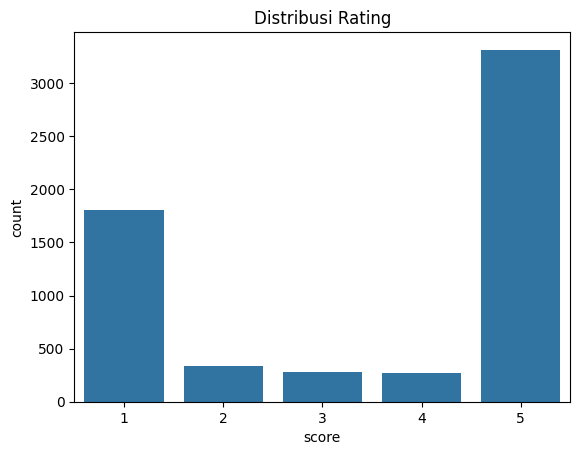

In [13]:
sns.countplot(x='score', data=df)
plt.title("Distribusi Rating")
plt.show()

In [14]:
df['sentiment'] = df['score'].apply(lambda x:
    'negative' if x <= 2 else
    'neutral' if x == 3 else
    'positive'
)

df['sentiment'].value_counts()

,count
sentiment,
positive,3581
negative,2142
neutral,277


dataset sangat imbalance di kelas positive, berpotensi model yang memiliki akurasi rendah, krn bobot data tidak seimbang

In [15]:
df['text_length'] = df['content'].apply(lambda x: len(str(x).split()))
df['text_length'].describe()

,text_length
count,6000.000000
mean,10.916833
std,14.788781
min,1.000000
25%,2.000000
50%,5.000000
75%,14.000000
max,96.000000


rata rata panjang kata adalah 10, sehingga ini adalah short text classification

# **Overview Proyek**

Tujuan:

Mengklasifikasikan sentimen ulasan Gojek menjadi 3 kelas yaitu
1. positive
2. neutral
4. negative

Karakteristik data berdasarkan hasil EDA:
1. dataset "short text"
2. data imbalance
3. bahasa informal atau memiliki banyak singkatan dan typo

Implikasi Metode:
1. TF-IDF efektif untuk short text
2. Logistic Regression kuat untuk sparse features
3. Perlu penanganan imbalance (SMOTE atau class_weight)

# **Implementasi**

In [16]:
# Data
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import re

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Imbalance
from imblearn.over_sampling import SMOTE

# DL
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.preprocessing import LabelEncoder

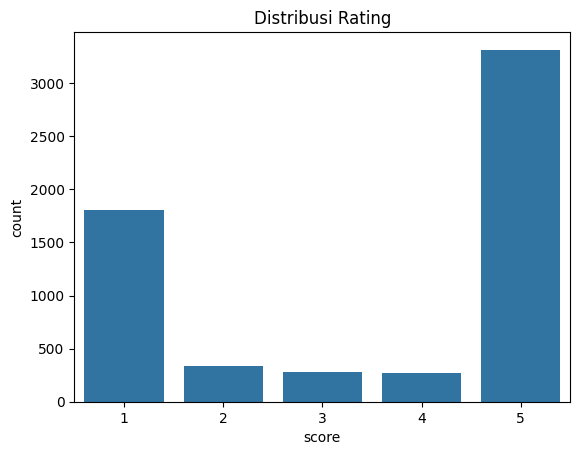

In [17]:
sns.countplot(x='score', data=df)
plt.title("Distribusi Rating")
plt.show()

In [18]:
def label_sentiment(score):
    if score <= 2:
        return 'negative'
    elif score == 3:
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['score'].apply(label_sentiment)

In [19]:
df['sentiment'].value_counts()

,count
sentiment,
positive,3581
negative,2142
neutral,277


Karena data Imbalance, berpotensi model akan bias, sehingga:
1. SMOTE untuk algoritma ML
2. class_weight untuk DL

**Text Preprocessing**

In [20]:
#membersihkan noise

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['content'].apply(clean_text)

**Feature Extraction (TF-IDF)**

TF-IDF mengukur pentingnya kata dalam dokumen, digunakan karena:
1. cocok untuk short text
2. interpretatif
3. dan cepat

In [21]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']

**Handling Imbalance (SMOTE)**

SMOTE, membuat data sintetis untuk kelas minoritas

In [22]:
smote = SMOTE()
X_res, y_res = smote.fit_resample(X, y)

**Split Data**

Menggunakan skenario 8:2

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, stratify=y_res, random_state=42
)

**Model 1: Naive Bayes**

In [27]:
nb = MultinomialNB()
nb.fit(X_train, y_train)

y_train_nb = nb.predict(X_train)
y_pred_nb = nb.predict(X_test)

print("NB Accuracy:", accuracy_score(y_test, y_pred_nb))
print ("NB Accuracy Training:", accuracy_score(y_train, y_train_nb))
print ("\n")
print(classification_report(y_train, y_train_nb))
print(classification_report(y_test, y_pred_nb))

NB Accuracy: 0.8776174965100046
NB Accuracy Training: 0.8939958110309518


              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      2865
     neutral       0.85      0.97      0.91      2865
    positive       0.96      0.84      0.89      2864

    accuracy                           0.89      8594
   macro avg       0.90      0.89      0.89      8594
weighted avg       0.90      0.89      0.89      8594

              precision    recall  f1-score   support

    negative       0.88      0.82      0.85       716
     neutral       0.82      0.97      0.89       716
    positive       0.95      0.84      0.89       717

    accuracy                           0.88      2149
   macro avg       0.88      0.88      0.88      2149
weighted avg       0.88      0.88      0.88      2149



**Model 2: Logistic Regression**

In [28]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_train_lr = lr.predict(X_train)

print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))
print ("LR Accuracy Training:", accuracy_score(y_train, y_train_lr))
print ("\n")
print(classification_report(y_train, y_train_lr))
print(classification_report(y_test, y_pred_lr))

LR Accuracy: 0.8864588180549092
LR Accuracy Training: 0.9150570165231557


              precision    recall  f1-score   support

    negative       0.85      0.96      0.90      2865
     neutral       0.95      0.91      0.92      2865
    positive       0.97      0.88      0.92      2864

    accuracy                           0.92      8594
   macro avg       0.92      0.92      0.92      8594
weighted avg       0.92      0.92      0.92      8594

              precision    recall  f1-score   support

    negative       0.83      0.90      0.87       716
     neutral       0.88      0.91      0.90       716
    positive       0.95      0.85      0.90       717

    accuracy                           0.89      2149
   macro avg       0.89      0.89      0.89      2149
weighted avg       0.89      0.89      0.89      2149



**Model 3: Deep Learning LSTM**

In [29]:
#tokenisasi

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['clean_text'])

X_seq = tokenizer.texts_to_sequences(df['clean_text'])
X_pad = pad_sequences(X_seq, maxlen=100)

In [30]:
#encode label

le = LabelEncoder()
y_encoded = le.fit_transform(df['sentiment'])

In [31]:
#split

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y_encoded, test_size=0.2, random_state=42
)

In [32]:
#model

model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))
model.add(LSTM(64))
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [34]:
#training

history = model.fit(
    X_train_dl, y_train_dl,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9656 - loss: 0.1143 - val_accuracy: 0.9729 - val_loss: 0.1018
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.9773 - loss: 0.0845 - val_accuracy: 0.9625 - val_loss: 0.1219
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9794 - loss: 0.0765 - val_accuracy: 0.9583 - val_loss: 0.1313
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9841 - loss: 0.0656 - val_accuracy: 0.9583 - val_loss: 0.1332
Epoch 5/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 10s 82ms/step - accuracy: 0.9878 - loss: 0.0535 - val_accuracy: 0.9531 - val_loss: 0.1534
Epoch 6/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step - accuracy: 0.9857 - loss: 0.0587 - val_accuracy: 0.9500 - val_loss: 0.1664
Epoch 7/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.9885 - loss: 0.0477 - val_accuracy: 0.9531 - val_loss: 0.1734
Epoch 8/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9893 - loss: 0.0422 - val_a

In [35]:
#evaluasi

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

train_loss = history.history['loss']
val_loss = history.history['val_loss']

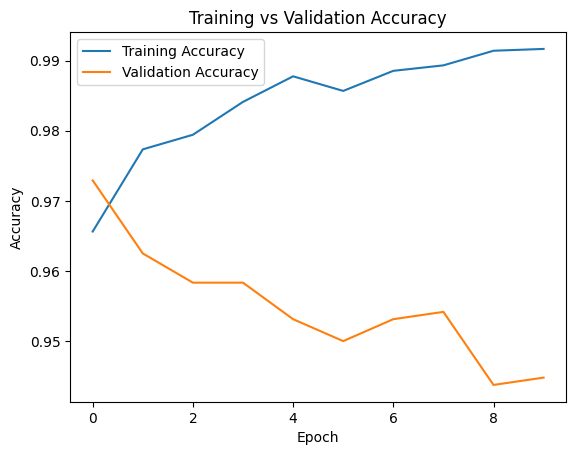

In [36]:
plt.figure()
plt.plot(train_acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

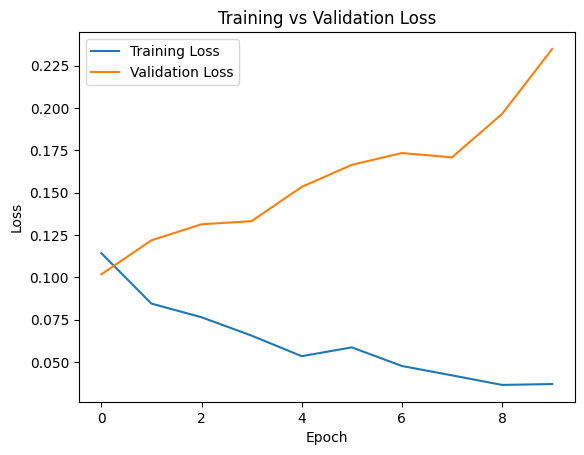

In [37]:
plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [38]:
#evaluasi testing

loss_test, acc_test = model.evaluate(X_test_dl, y_test_dl)
print("Test Accuracy:", acc_test)
print("Test Loss:", loss_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8583 - loss: 0.8226
Test Accuracy: 0.8583333492279053
Test Loss: 0.8226367831230164


In [39]:
y_pred_dl = model.predict(X_test_dl)
y_pred_dl = np.argmax(y_pred_dl, axis=1)

from sklearn.metrics import classification_report
print(classification_report(y_test_dl, y_pred_dl))

38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step
              precision    recall  f1-score   support

           0       0.77      0.89      0.83       416
           1       0.07      0.02      0.03        55
           2       0.93      0.90      0.92       729

    accuracy                           0.86      1200
   macro avg       0.59      0.60      0.59      1200
weighted avg       0.84      0.86      0.85      1200



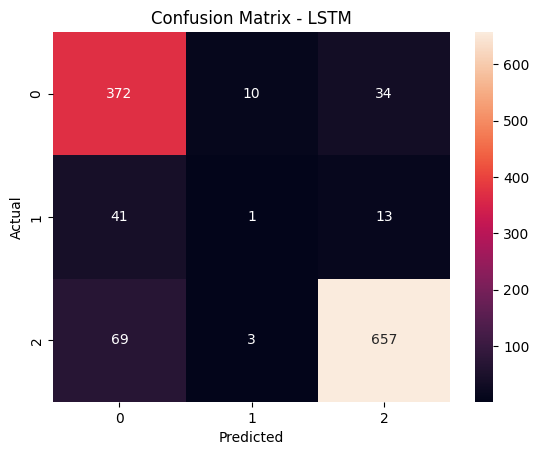

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_dl, y_pred_dl)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix - LSTM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [41]:
#Resume Evaluasi Final

train_acc_final = history.history['accuracy'][-1]
print("Training Accuracy:", train_acc_final)

val_acc_final = history.history['val_accuracy'][-1]
print("Validation Accuracy:", val_acc_final)

loss_test, acc_test = model.evaluate(X_test_dl, y_test_dl)
print("Testing Accuracy:", acc_test)

Training Accuracy: 0.9916666746139526
Validation Accuracy: 0.9447916746139526
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8583 - loss: 0.8226
Testing Accuracy: 0.8583333492279053


# **Inference**

menggunakan model Naive Bayes, dikarenakan dari hasil akurasi model lainnya model NB memiliki hasil yang stabil

In [42]:
import pickle

# Simpan model
with open('model_nb.pkl', 'wb') as f:
    pickle.dump(nb, f)

# Simpan TF-IDF
with open('tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

In [43]:
import pickle

# Load model
with open('model_nb.pkl', 'rb') as f:
    model = pickle.load(f)

# Load TF-IDF
with open('tfidf.pkl', 'rb') as f:
    vectorizer = pickle.load(f)

In [44]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [45]:
def predict_sentiment(text):
    # preprocessing
    cleaned = clean_text(text)

    # ubah ke TF-IDF
    vectorized = vectorizer.transform([cleaned])

    # prediksi
    prediction = model.predict(vectorized)

    return prediction[0]

In [47]:
text1 = "aplikasi jelek, proses lama, driver juga ga sopan"
text2 = "aplikasinya bagus banget"
text3 = "lumayan sih tapi kadang error"

print(predict_sentiment(text1))
print(predict_sentiment(text2))
print(predict_sentiment(text3))

negative
positive
neutral
